In [1]:
import apoc
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import os 
from skimage import io
import time
import pandas as pd
from IPython.display import HTML

In [2]:
plt.close("all")

In [9]:
cl_filename = r"D:\Uni\Master\Masterarbeit\Image Analysis\Machine Learning Models\test_object_segmenter_old_staining.cl"

In [12]:
classifier = apoc.PixelClassifier(opencl_filename=cl_filename)

shares, counts = classifier.statistics()

def colorize(styler):
    styler.background_gradient(axis=None, cmap="rainbow")
    return styler

df = pd.DataFrame(shares).T
counts_df = pd.DataFrame(counts).T
counts_df_styled = counts_df.style.pipe(colorize)
df_styled=df.style.pipe(colorize)
df_html = df_styled.to_html()


# write html to file
#text_file = open(r"D:\Uni\Promotion\Vortrag Systembio\ML_stats.html", "w")
#text_file.write(df_html)
#text_file.close()
display(counts_df_styled)

#df.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Figures\Dataframes for figures\ML_stats_exp_2.3.csv")

,0,1,2,3,4
sobel_of_gaussian_blur=2,0,12,4,8,21
sobel_of_gaussian_blur=4,42,34,100,180,346
laplace_box_of_gaussian_blur=2,42,51,146,318,579
laplace_box_of_gaussian_blur=4,2,51,75,125,286
gaussian_blur=1,0,11,10,22,54
gaussian_blur=2,3,15,23,35,55
gaussian_blur=4,3,12,17,40,99
gaussian_blur=8,6,13,18,62,120


In [24]:
print(classifier.feature_specification)
print(classifier.opencl_file)

top_hat_box=10 small_hessian_eigenvalue_of_gaussian_blur=1 large_hessian_eigenvalue_of_gaussian_blur=1 laplace_box_of_gaussian_blur=2 laplace_box_of_gaussian_blur=4 gaussian_blur=1 gaussian_blur=2 gaussian_blur=4 gaussian_blur=8
D:/Uni/Master/Masterarbeit/Image Analysis/Machine Learning Models/pixel_segmenter_new_staining_from_scratch_CHs_EEA1_LAMP1_NR_Exp_4-6_new.cl


In [25]:
base_path = r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_5"

probe = "NR7_1nM_plus_benzo_tr1"

# find all cycle folders
cycle_folders = [f for f in os.listdir(base_path) if probe in f]
cycle_folders = sorted(cycle_folders)

print(cycle_folders)


['NR7_1nM_plus_benzo_tr1_Cycle', 'NR7_1nM_plus_benzo_tr1_Cycle_01']


### Generate Masks

Start Cycle: NR7_1nM_plus_benzo_tr1_Cycle
[NR7_1nM_plus_benzo_tr1_Cycle] Frame 1/9 (11%) → NR7_1nM_plus_benzo_tr1_A01_G018_0001.frames
result uint32 (1024, 1024)


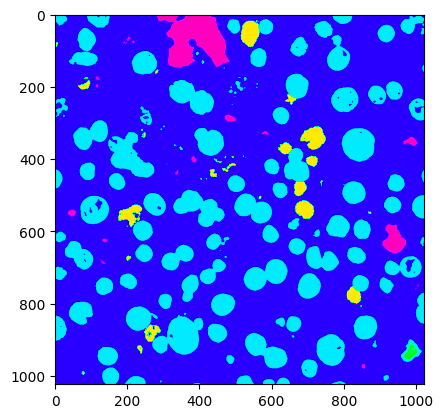

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 2/9 (22%) → NR7_1nM_plus_benzo_tr1_A01_G018_0002.frames
result uint32 (1024, 1024)


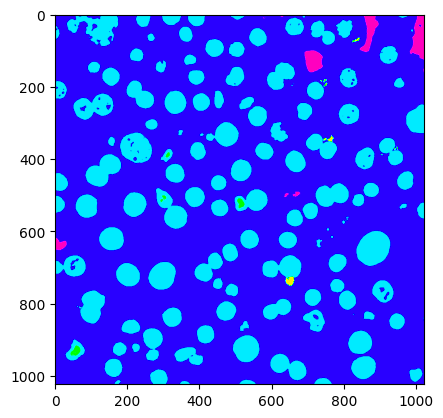

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 3/9 (33%) → NR7_1nM_plus_benzo_tr1_A01_G018_0003.frames
result uint32 (1024, 1024)


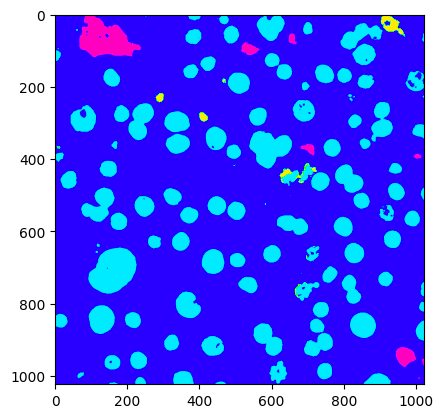

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 4/9 (44%) → NR7_1nM_plus_benzo_tr1_A01_G018_0004.frames
result uint32 (1024, 1024)


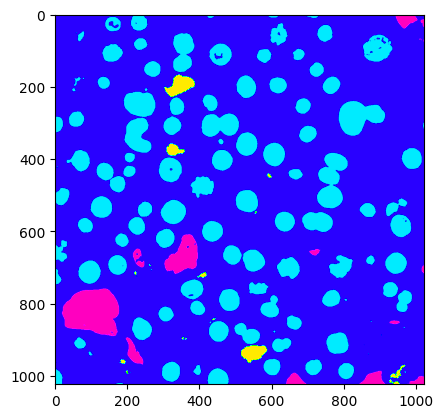

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 5/9 (56%) → NR7_1nM_plus_benzo_tr1_A01_G018_0005.frames
result uint32 (1024, 1024)


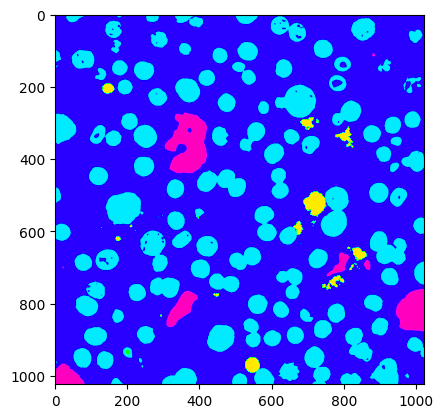

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 6/9 (67%) → NR7_1nM_plus_benzo_tr1_A01_G018_0006.frames
result uint32 (1024, 1024)


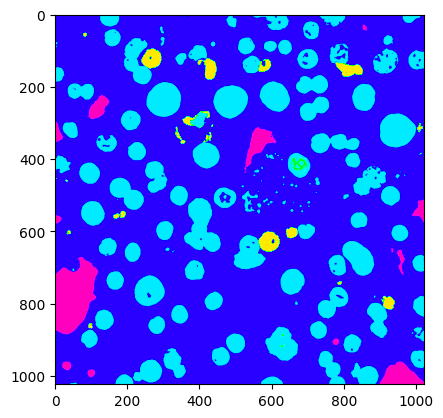

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 7/9 (78%) → NR7_1nM_plus_benzo_tr1_A01_G018_0007.frames
result uint32 (1024, 1024)


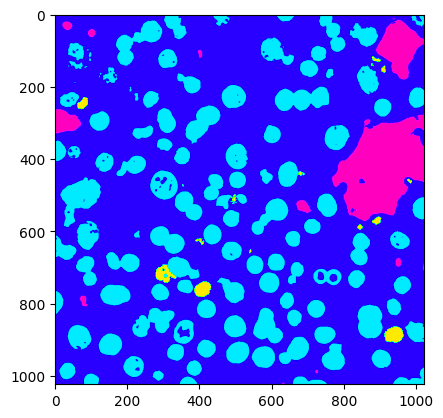

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 8/9 (89%) → NR7_1nM_plus_benzo_tr1_A01_G018_0008.frames
result uint32 (1024, 1024)


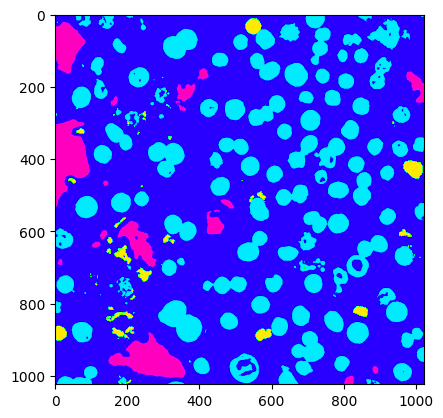

[NR7_1nM_plus_benzo_tr1_Cycle] Frame 9/9 (100%) → NR7_1nM_plus_benzo_tr1_A01_G018_0009.frames
result uint32 (1024, 1024)


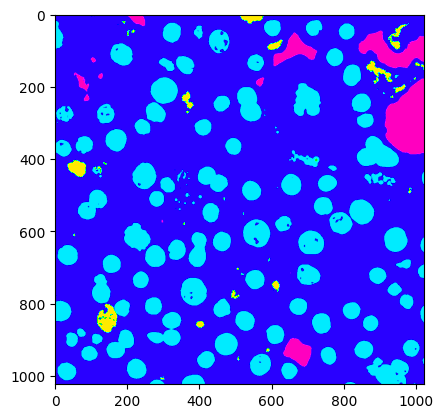

Start Cycle: NR7_1nM_plus_benzo_tr1_Cycle_01
[NR7_1nM_plus_benzo_tr1_Cycle_01] Frame 1/4 (25%) → NR7_1nM_plus_benzo_tr1_A01_G013_0001.frames
result uint32 (1024, 1024)


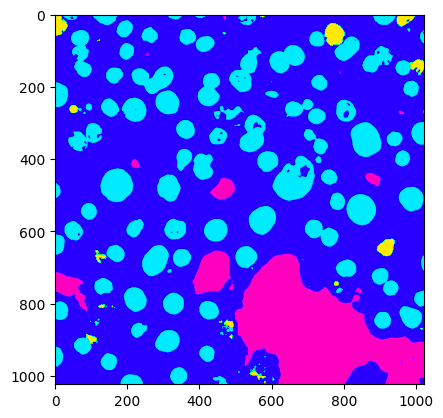

[NR7_1nM_plus_benzo_tr1_Cycle_01] Frame 2/4 (50%) → NR7_1nM_plus_benzo_tr1_A01_G013_0002.frames
result uint32 (1024, 1024)


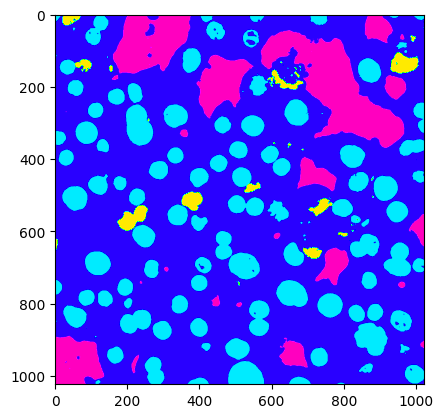

[NR7_1nM_plus_benzo_tr1_Cycle_01] Frame 3/4 (75%) → NR7_1nM_plus_benzo_tr1_A01_G013_0003.frames
result uint32 (1024, 1024)


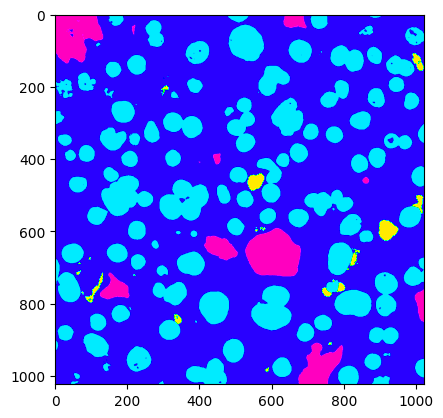

[NR7_1nM_plus_benzo_tr1_Cycle_01] Frame 4/4 (100%) → NR7_1nM_plus_benzo_tr1_A01_G013_0004.frames
result uint32 (1024, 1024)


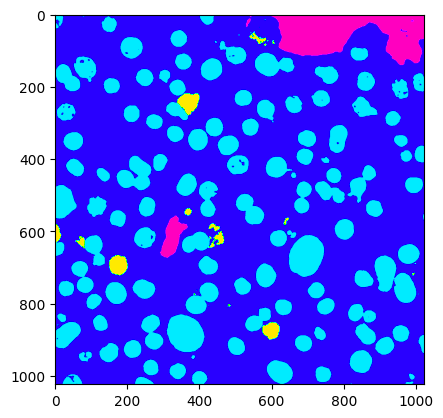

done


In [26]:
for cycle in cycle_folders:
    print(f"Start Cycle: {cycle}")
    cycle_path = os.path.join(base_path, cycle)
    frame_folders = [f for f in os.listdir(cycle_path) if f.endswith(".frames")]

    #frame_folders = frame_folders[:2]
    total_frames = len(frame_folders)

    for i, frame in enumerate(frame_folders, start=1):
        if not [frame_folders]:
            continue
        frame_path = os.path.join(cycle_path, frame)
        dapi, lyso, endo, nr = None, None, None, None
        print(f"[{cycle}] Frame {i}/{total_frames} ({i/total_frames:.0%}) → {frame}")

        
                # --- load channels ---
        for file in os.listdir(frame_path):
            full_path = os.path.join(frame_path, file)
            
            if "C001" in file:
                dapi = io.imread(full_path)
            elif "C002" in file:
                lyso = io.imread(full_path)
            elif "C003" in file:
                endo = tiff.imread(full_path)
            elif "C004" in file:
                nr = io.imread(full_path)
        
        if any(x is None for x in (dapi, lyso, endo, nr)):
            print("missing channel:", frame)
            continue

        sample_name= frame.replace(".tif.frames", "")
        
        result = classifier.predict(image=[dapi, lyso, endo, nr])
        prob_map = classifier.predict(image=[dapi, lyso, endo, nr])

        print("result", result.dtype, result.shape)
        plt.figure()
        plt.imshow(result, cmap= "gist_rainbow",  vmin=0, vmax=5)
        plt.show()
      
        
        #tiff.imwrite(os.path.join(frame_path, f"{sample_name}_mask.tif"), result)

        # small GPU breathing room
        time.sleep(0.05)

print("done")

## Test

### Test single images

In [17]:
dapi=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_C001T001.tif")
lyso=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_C002T001.tif")
endo=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_C003T001.tif")
nr=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_C004T001.tif")

mask=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_mask.tif")



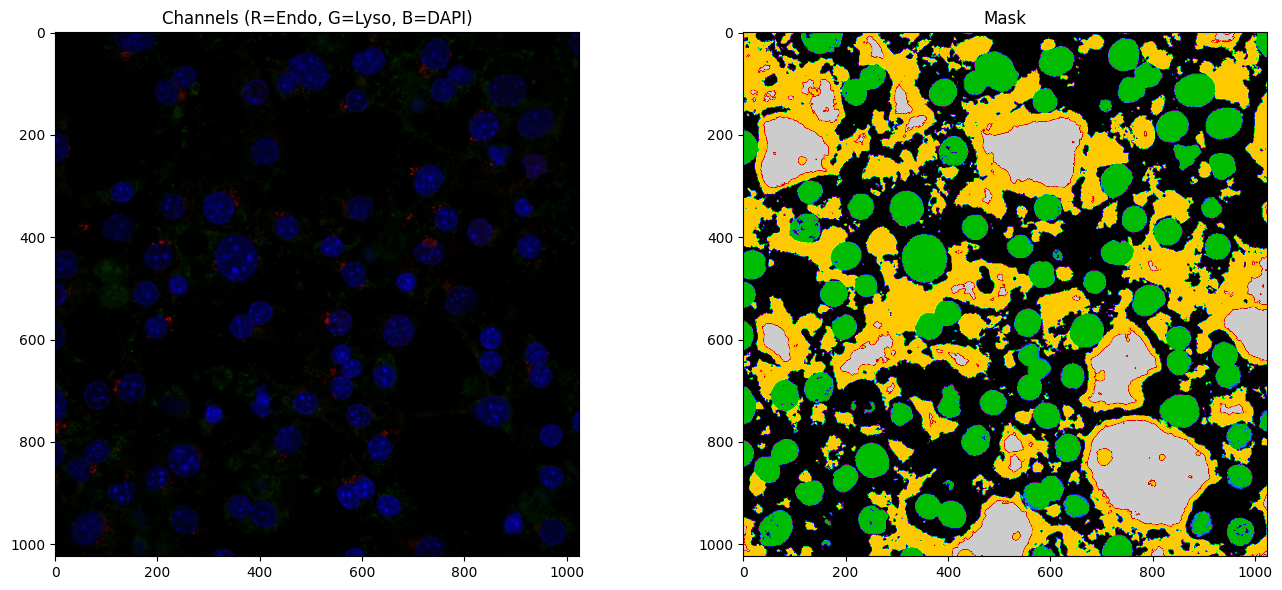

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalisierung für bessere Darstellung
def norm(img):
    return (img - img.min()) / (img.max() - img.min())

# RGB Overlay aus 3 Kanälen (DAPI=blau, Lyso=grün, Endo=rot)
rgb = np.stack([norm(endo), norm(lyso), norm(dapi)], axis=-1)

axes[0].imshow(rgb)
axes[0].set_title("Channels (R=Endo, G=Lyso, B=DAPI)")

axes[1].imshow(mask, cmap="nipy_spectral")
axes[1].set_title("Mask")

plt.tight_layout()

plt.show()

In [19]:
#control
dapi = io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\Nicht für Quantifizierung verwenden\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C001T001.tif")
print("dapi", dapi.shape, dapi.dtype)
lyso = io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\Nicht für Quantifizierung verwenden\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C002T001.tif")
print("lyso", lyso.shape, lyso.dtype)
endo = io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\Nicht für Quantifizierung verwenden\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C003T001.tif")
print("endo", endo.shape, endo.dtype)
nr= io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\Nicht für Quantifizierung verwenden\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C004T001.tif")
print("nr", nr.shape, nr.dtype)



FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Uni\\Master\\Masterarbeit\\Experimental Data\\Export_Exp-2.3\\Gray scale\\Nicht für Quantifizierung verwenden\\ctrl_Cycle_01\\ctrl.tif.frames\\ctrl_C001T001.tif'

In [ ]:
result = classifier.predict(image=[dapi, lyso, endo, nr])
tiff.imwrite(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_mask_test.tif", result)


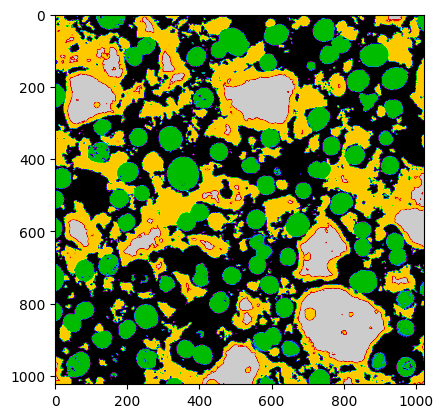

In [41]:
#dapi=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C001T001.tif")
#lyso=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C002T001.tif")
#endo=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C003T001.tif")
#nr=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp-2.3\Gray scale\ctrl_Cycle_01\ctrl.tif.frames\ctrl_C004T001.tif")

mask=io.imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_10nM_new_new_Cycle_01\NR7_10nM_new_new_A01_G005_0004.tif.frames\NR7_10nM_new_new_A01_G005_0004_mask_test.tif")
plt.imshow(mask, cmap= "nipy_spectral")


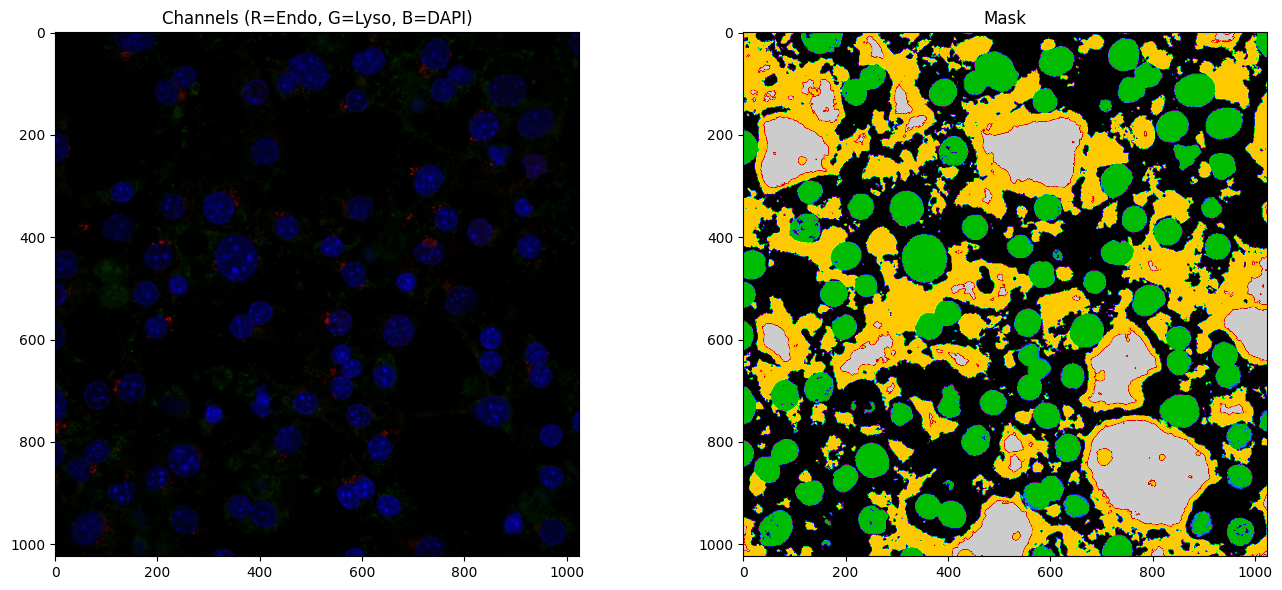

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalisierung für bessere Darstellung
def norm(img):
    return (img - img.min()) / (img.max() - img.min())

# RGB Overlay aus 3 Kanälen (DAPI=blau, Lyso=grün, Endo=rot)
rgb = np.stack([norm(endo), norm(lyso), norm(dapi)], axis=-1)

axes[0].imshow(rgb)
axes[0].set_title("Channels (R=Endo, G=Lyso, B=DAPI)")

axes[1].imshow(mask, cmap="nipy_spectral")
axes[1].set_title("Mask")

plt.tight_layout()

plt.show()